In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
input_with_all = """graph_walk: 222.44 seconds.
graph_bike: 227.61 seconds.
graph_walk_pt: 244.23 seconds.

graph_walk: 221.54 seconds.
graph_bike: 228.08 seconds.
graph_walk_pt: 248.47 seconds.

graph_walk: 222.53 seconds.
graph_bike: 228.55 seconds.
graph_walk_pt: 260.84 seconds.

graph_walk: 220.51 seconds.
graph_bike: 227.88 seconds.
graph_walk_pt: 248.54 seconds.

graph_walk: 221.65 seconds.
graph_bike: 232.63 seconds.
graph_walk_pt: 243.89 seconds."""

input_without_heat = """graph_walk: 48.84 seconds.
graph_bike: 48.72 seconds.
graph_walk_pt: 62.94 seconds.

graph_walk: 49.19 seconds.
graph_bike: 50.01 seconds.
graph_walk_pt: 63.12 seconds.

graph_walk: 49.33 seconds.
graph_bike: 50.21 seconds.
graph_walk_pt: 62.38 seconds.

graph_walk: 48.72 seconds.
graph_bike: 49.62 seconds.
graph_walk_pt: 61.57 seconds.

graph_walk: 49.79 seconds.
graph_bike: 51.66 seconds.
graph_walk_pt: 62.76 seconds."""

input_without_inclination = """graph_walk: 222.21 seconds.
graph_bike: 232.78 seconds.
graph_walk_pt: 244.47 seconds.

graph_walk: 224.72 seconds.
graph_bike: 228.85 seconds.
graph_walk_pt: 245.08 seconds.

graph_walk: 220.55 seconds.
graph_bike: 224.53 seconds.
graph_walk_pt: 243.59 seconds.

graph_walk: 221.08 seconds.
graph_bike: 227.84 seconds.
graph_walk_pt: 244.19 seconds.

graph_walk: 224.36 seconds.
graph_bike: 227.64 seconds.
graph_walk_pt: 242.20 seconds."""

In [4]:
def input_to_df(input_with_all):
    data = []
    for block in input_with_all.replace("graph_", "").replace(" seconds.", "").split("\n\n"):
        lines = block.strip().split("\n")
        row = {}
        for line in lines:
            mode, time = line.split(": ")
            row[mode] = float(time)
        data.append(row)
    return pd.DataFrame(data)

df_all = input_to_df(input_with_all)
df_without_heat = input_to_df(input_without_heat)
df_without_inclination = input_to_df(input_without_inclination)

In [14]:
df_all.sum(axis=1).mean()

np.float64(699.8779999999999)

In [19]:
df_all

,walk,bike,walk_pt
0,222.44,227.61,244.23
1,221.54,228.08,248.47
2,222.53,228.55,260.84
3,220.51,227.88,248.54
4,221.65,232.63,243.89


In [27]:
" & ".join(df_without_inclination["walk_pt"].astype(str))

'244.47 & 245.08 & 243.59 & 244.19 & 242.2'

In [6]:
df_all.mean().mean()

np.float64(233.29266666666663)

In [7]:
df_all

,walk,bike,walk_pt
0,222.44,227.61,244.23
1,221.54,228.08,248.47
2,222.53,228.55,260.84
3,220.51,227.88,248.54
4,221.65,232.63,243.89


In [8]:
df = pd.DataFrame({
    "walk": {
        "with all": df_all["walk"].mean(),
        "without heat": df_without_heat["walk"].mean(),
        "without inclination": df_without_inclination["walk"].mean(),
    },
    "bike": {
        "with all": df_all["bike"].mean(),
        "without heat": df_without_heat["bike"].mean(),
        "without inclination": df_without_inclination["bike"].mean(),
    },
    "walk PT": {
        "with all": df_all["walk_pt"].mean(),
        "without heat": df_without_heat["walk_pt"].mean(),
        "without inclination": df_without_inclination["walk_pt"].mean(),

    }
})

In [9]:
df

,walk,bike,walk PT
with all,221.734,228.950,249.194
without heat,49.174,50.044,62.554
without inclination,222.584,228.328,243.906


In [10]:
df.index

Index(['with all', 'without heat', 'without inclination'], dtype='str')

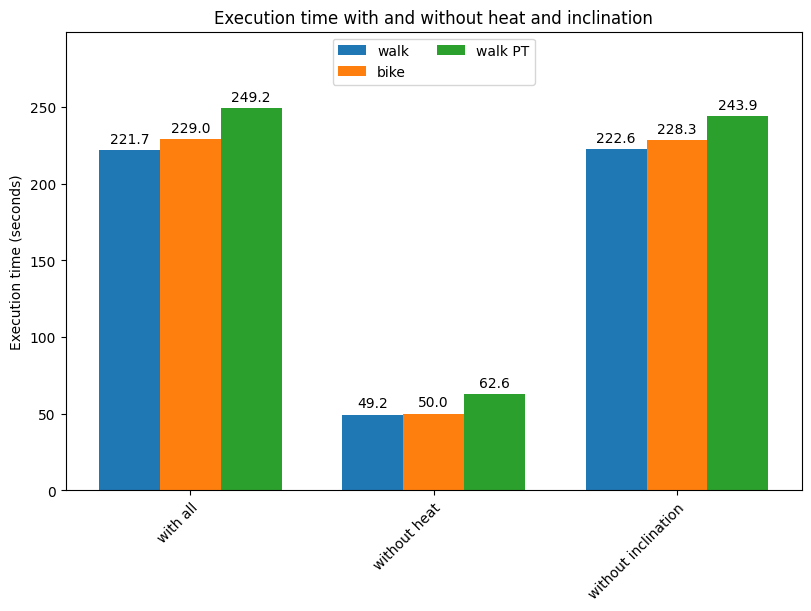

In [11]:
configurations = list(df.index)

n_s = {
    "walk": list(df["walk"]),
    "bike": list(df["bike"]),
    "walk PT": list(df["walk PT"]),
}

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(8, 6))


max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement, 1)

    max_value = max(max_value, max(measurement))
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}" for val in measurement],
        padding=3,
    )
    multiplier += 1

ax.set_ylabel("Execution time (seconds)")
ax.set_title("Execution time with and without heat and inclination")
ax.set_xticks(
    x + width,
    configurations,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)
ax.legend(loc="upper center", ncols=2)
ax.set_ylim(0, max_value + 50)

plt.show()